**In this Notebook, I am getting familiar with the [modern dataset (Chen)](https://zenodo.org/records/7306199) (download the *.nc* file).**

This dataset is not a direct output from isotope-enabled GCMs. Instead, it has been generated through data fusion and bias correction techniques based on GCM outputs. In other words, post-processing methods were applied to the model outputs to bring the simulations closer to observational data. This dataset is 1870–2017 at a monthly scale.

First, we import useful libraries and read the netCTF4 file with xarray to get a Dataset object. 

In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt 
import numpy as np
import plotly as px
import cartopy.crs as ccrs
import seaborn as sns
import skgstat as skg
import geopandas as gpd
from shapely.geometry import Point
from pyproj import Transformer
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import pdist

sns.set_style('darkgrid')
fn = '../data/modern/PrecipOxygenIso_mainlandCHINA_1870to2017_v2.nc'

In [2]:
with xr.open_dataset(filename_or_obj=fn, engine='netcdf4',decode_times=False) as file:
    d18Op = file.d18Op

# make the time dimension a datetime index, starting from 1870-01-01, with monthly frequence so that time 1 becomes 1870-02-01, etc.
time_index = pd.date_range(start='1870-01-31', periods=d18Op.sizes['time'], freq='ME')
d18Op = d18Op.assign_coords(time=time_index)

print(d18Op)

<xarray.DataArray 'd18Op' (time: 1776, lon: 87, lat: 64)> Size: 79MB
[9888768 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 512B 53.1 52.44 51.83 51.24 ... 21.63 21.12 20.61
  * lon      (lon) float64 696B 73.74 74.4 75.06 75.72 ... 131.4 132.7 134.1
  * time     (time) datetime64[ns] 14kB 1870-01-31 1870-02-28 ... 2017-12-31
Attributes:
    long_name:  d18O in precipitation
    units:      permillage


Now, we can try to plot the data by setting different spatio-temporal ranges.

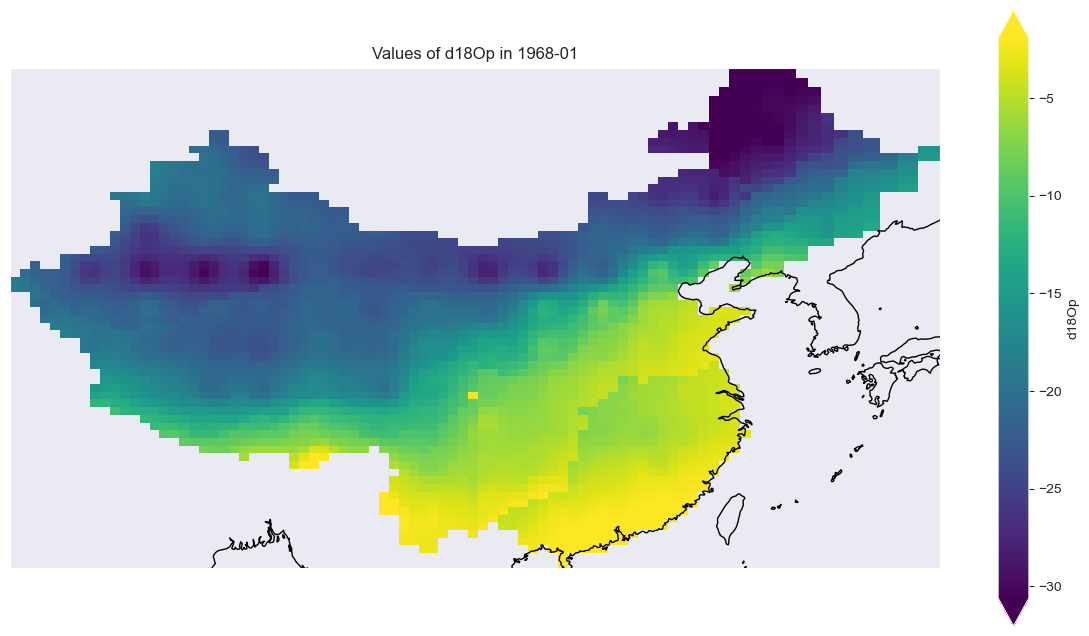

In [80]:
# Plot with cartopy
da_sel = d18Op.transpose('time','lat','lon').sel(time='1968-01-31') #1775
fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={"projection": ccrs.PlateCarree()})
da_sel.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    cbar_kwargs={"label": da_sel.name},
    robust=True
)

ax.coastlines()
# title with the year and the month
ax.set_title(f"Values of d18Op in {da_sel.time.values.astype('M8[M]').astype(str)}")
# plt.savefig("../output/itrace_artifacts_example.png",dpi=400)
plt.show()

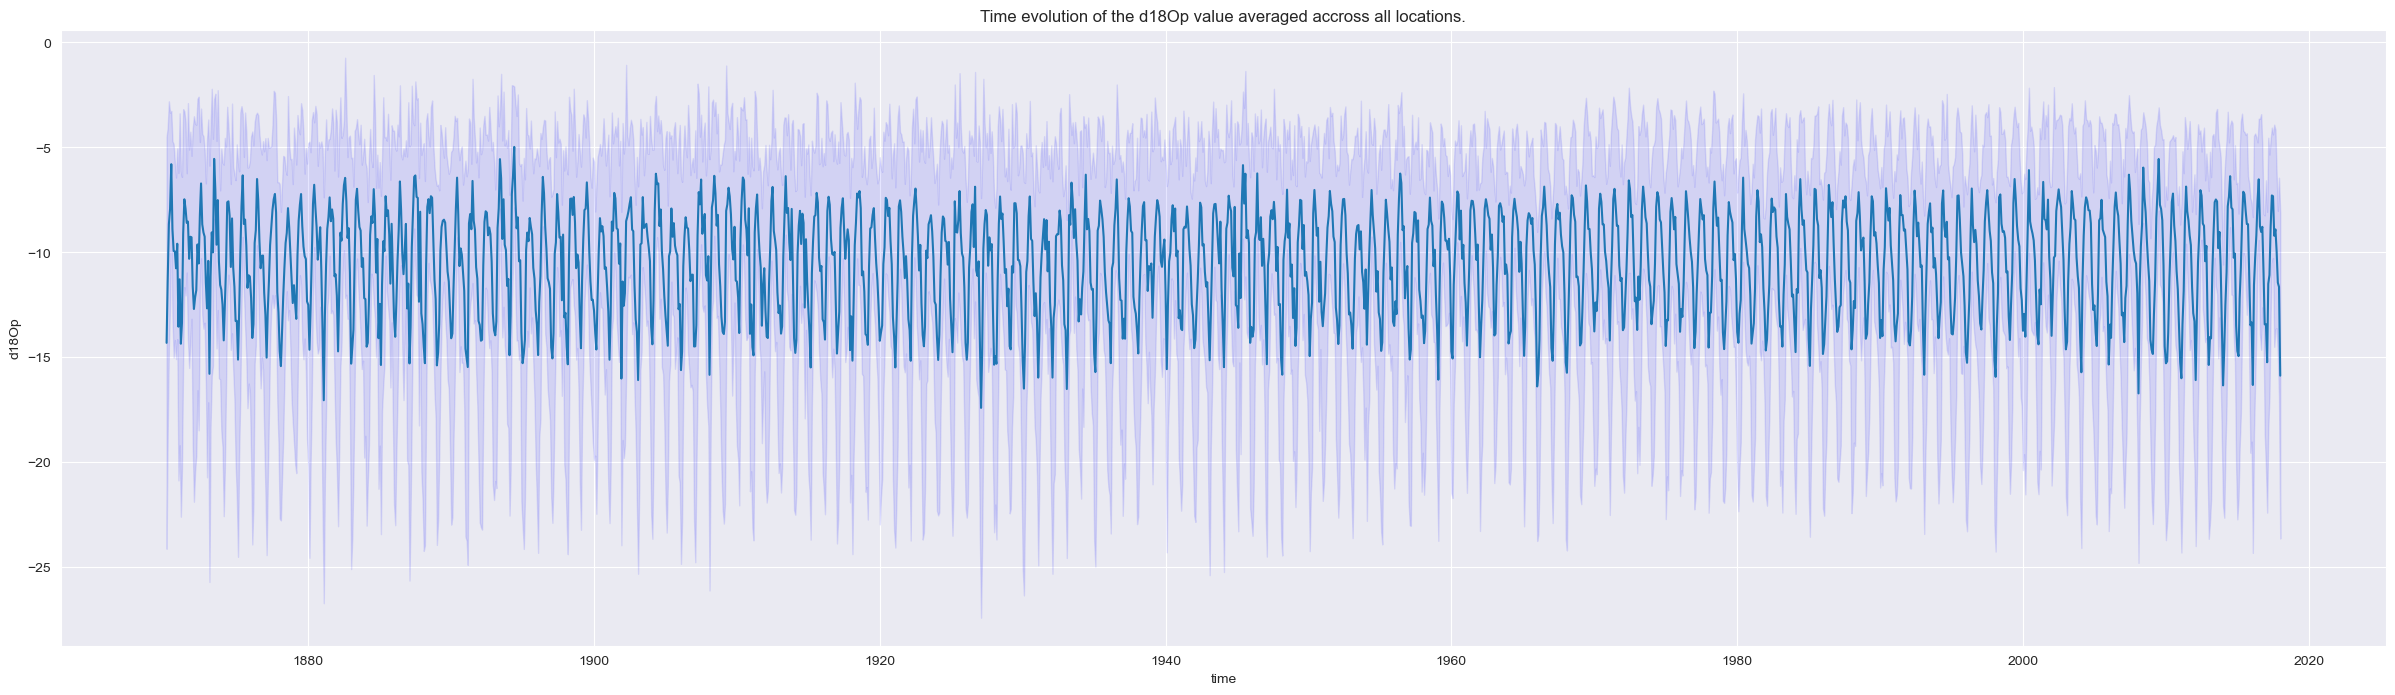

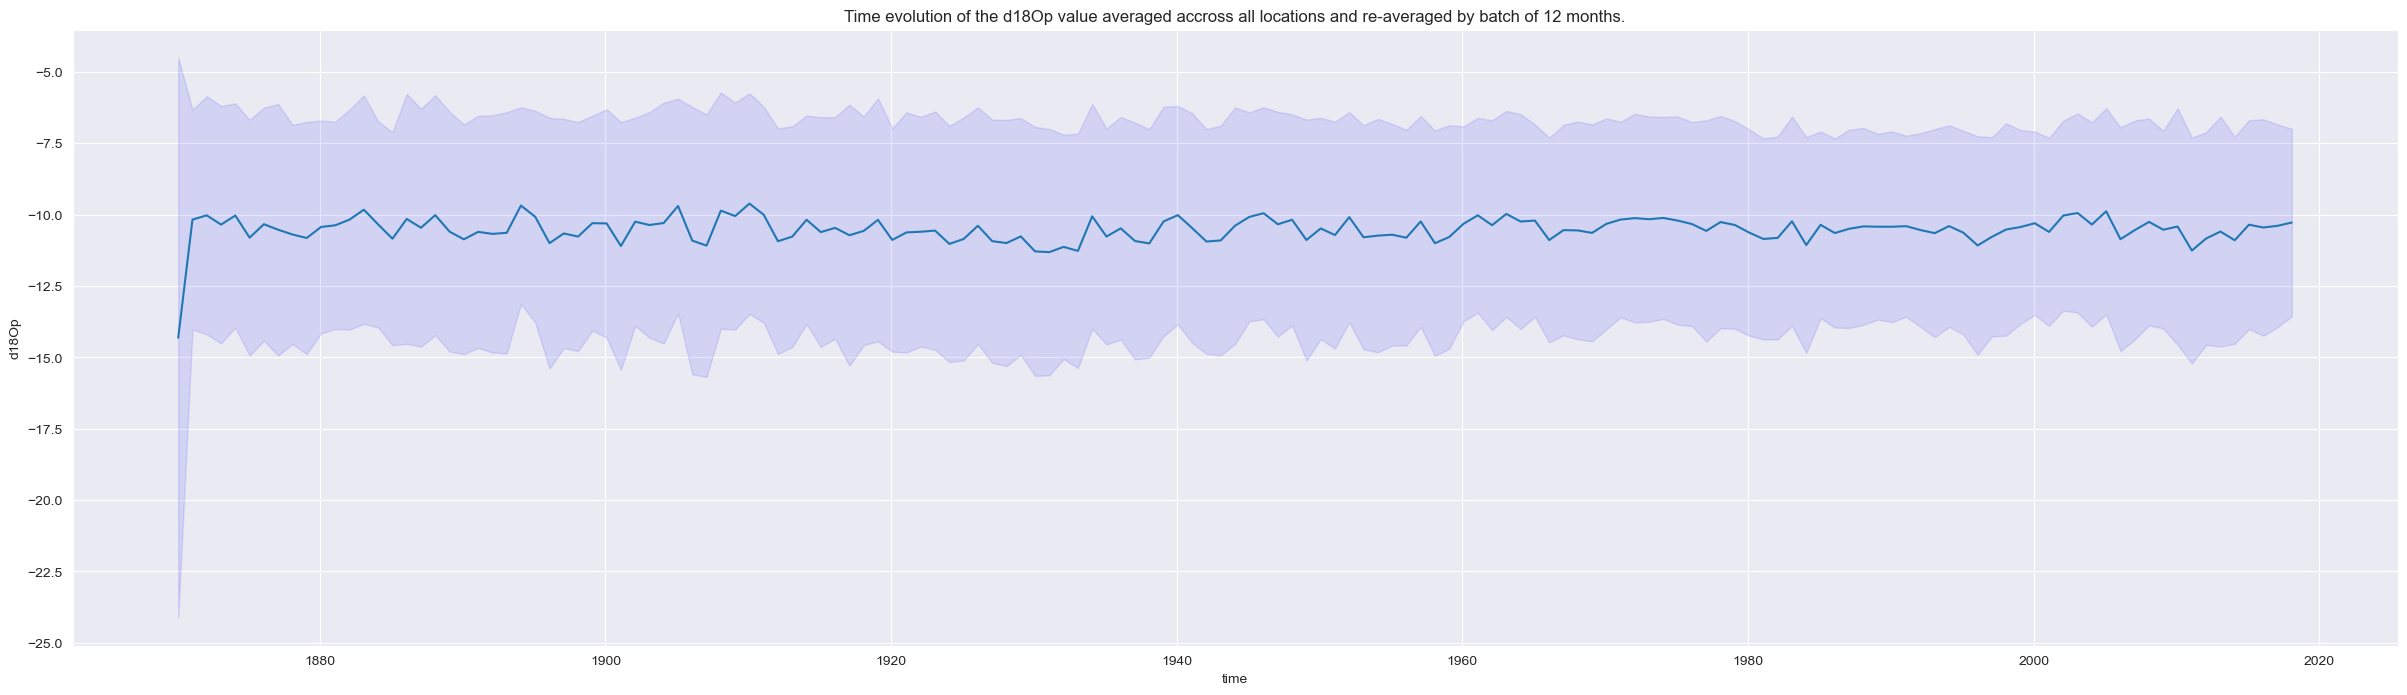

In [7]:
# Mean across all lat/lon with std shown
global_std = d18Op.std(dim=("lat", "lon"))
plt.figure(figsize=(30,8))
global_mean = d18Op.mean(dim=("lat", "lon"))
global_mean.plot.line(x="time")
plt.fill_between(global_mean.time.values, 
                 (global_mean - global_std).values, 
                 (global_mean + global_std).values, 
                 color='b', alpha=0.1, label='±1 std dev')
plt.title('Time evolution of the d18Op value averaged accross all locations.')
plt.show()

# Mean across all lat/lon re-averaged by batch of 12 months
plt.figure(figsize=(30,8))

global_mean_12m = d18Op.resample(time='12ME').mean().mean(dim=("lat", "lon"))
global_std_12m = d18Op.resample(time='12ME').mean().std(dim=("lat", "lon"))
global_mean_12m.plot.line(x="time")
plt.fill_between(global_mean_12m.time.values, 
                 (global_mean_12m - global_std_12m).values, 
                 (global_mean_12m + global_std_12m).values, 
                 color='b', alpha=0.1, label='±1 std dev')
plt.title('Time evolution of the d18Op value averaged accross all locations and re-averaged by batch of 12 months.')
plt.show()

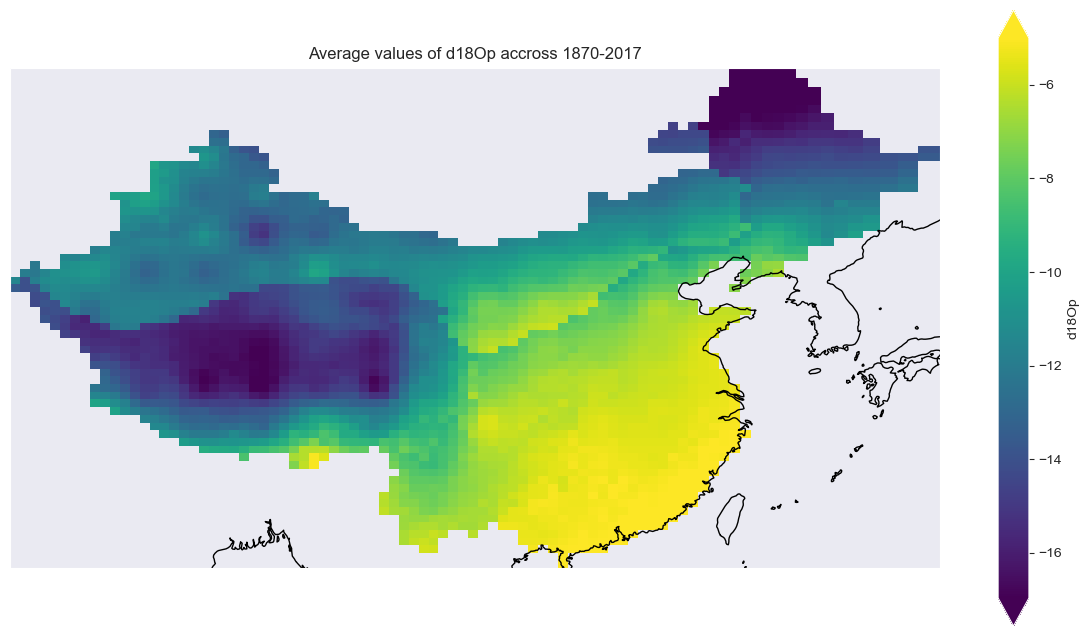

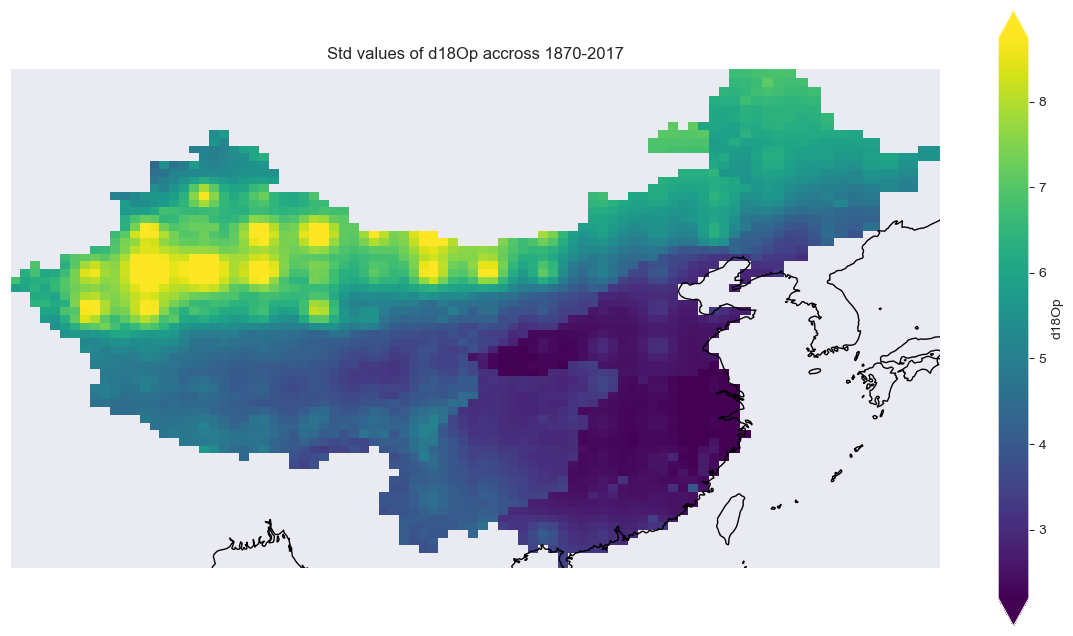

In [8]:
# mean and variance accross time
mean_d18Op = d18Op.transpose('time','lat','lon').mean(dim="time")
std_d18Op = d18Op.transpose('time','lat','lon').std(dim="time")   

fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={"projection": ccrs.PlateCarree()})
mean_d18Op.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    cbar_kwargs={"label": mean_d18Op.name},
    robust=True
)
ax.coastlines()
ax.set_title(f"Average values of d18Op accross 1870-2017")
plt.show()


fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={"projection": ccrs.PlateCarree()})
std_d18Op.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    cbar_kwargs={"label": std_d18Op.name},
    robust=True
)
ax.coastlines()
ax.set_title(f"Std values of d18Op accross 1870-2017")
plt.show()


High varibaility in NW region was explained by authors in the dataset's paper :

*"For NW, the variability of δ18Op simulations is also large. This is because, on the one hand, the sparse coverage of stations coupled with complex topography over northwest China cannot well represent the full range of precipitation isotope conditions. This can lead to biases in the distribution of observations. On the other hand, the arid northwest region is one of the most sensitive regions to climate change due to its fragile ecosystem, which affects sub-cloud evaporation and local moisture re-cycling, leading to the large uncertainty in isotope simulation between different iGCMs23,81."*

### Variogram by month

In [26]:
time = '2006-12-31' 

#### Expermiental Variogram (gstat, Euclidean distances) 

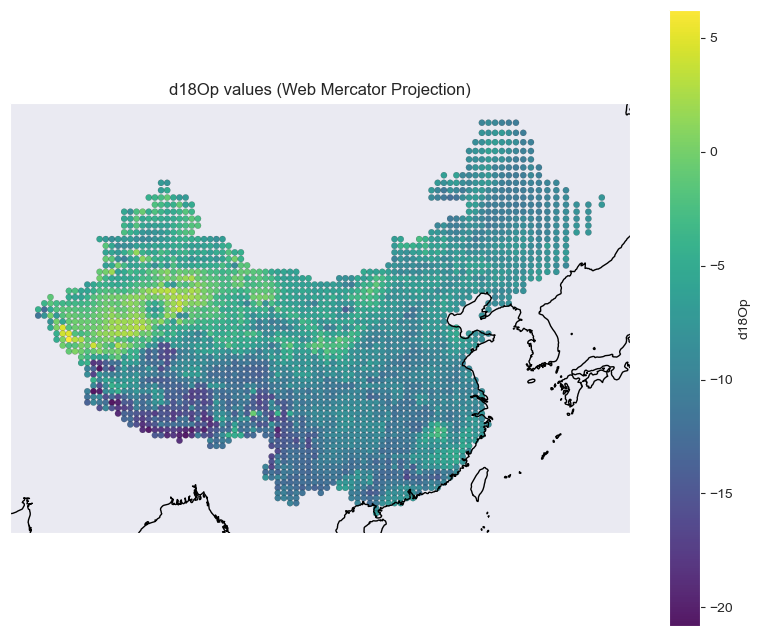

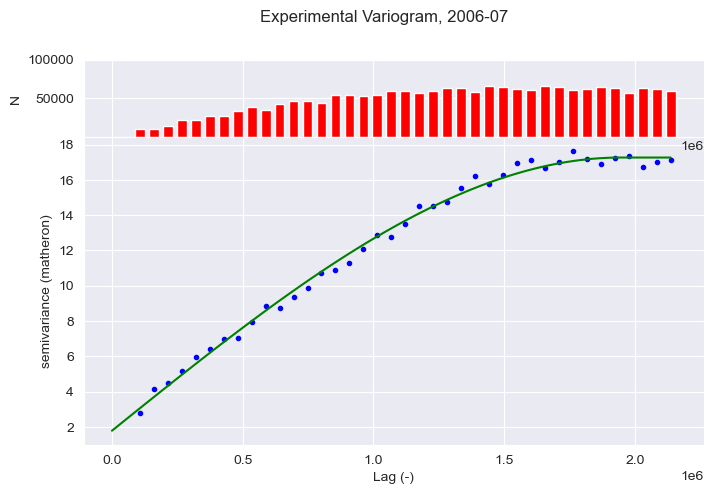

In [25]:
da_slice = d18Op.sel(time=time)

# flatten with xarray (no meshgrid/ravel headaches)
stacked = da_slice.stack(point=('lat','lon')).dropna('point') 
lons_s = stacked['lon'].values
lats_s = stacked['lat'].values
vals_s = stacked.values

# project vectorized
transformer = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True)
xs, ys = transformer.transform(lons_s, lats_s)
coords_proj = np.column_stack([xs, ys])

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.Mercator()})
sc = ax.scatter(coords_proj[:,0],coords_proj[:,1], c=vals_s, s=20, cmap="viridis", transform=ccrs.Mercator(), alpha=0.9, edgecolor="k", linewidth=0.1)
ax.coastlines(resolution="50m")
ax.set_title("d18Op values (Web Mercator Projection)")
plt.colorbar(sc, ax=ax, label="d18Op")
plt.show()

V = skg.Variogram(coords_proj, vals_s,
                  n_lags=40,
                  maxlag='median',
                  model='spherical',
                  use_nugget=True,
                  normalize=False)
fig = V.plot(show=False, grid=False)
fig.suptitle('Experimental Variogram, {}'.format(str(da_slice.time.values.astype('M8[M]').astype(str))))
fig.show()

#### Experimental Variogram of the **residuals** after trend removal (gstat, Euclidean distances)

Var(original) = 15.952839080788884  Var(residual) = 11.645206190377348


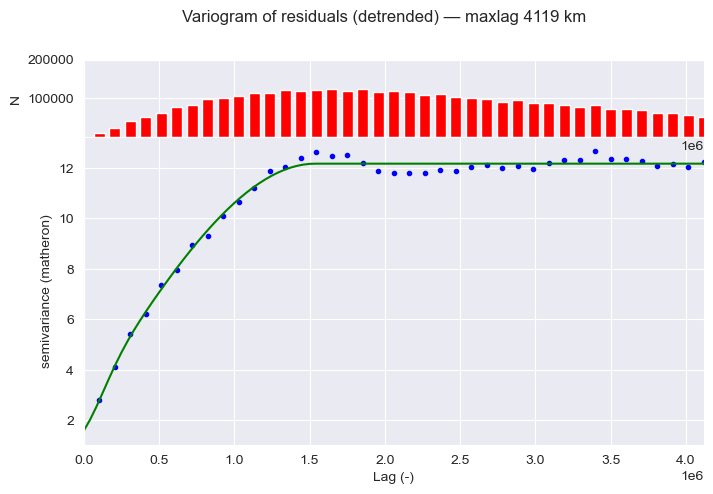

In [ ]:
da_slice = d18Op.sel(time=time)

# flatten with xarray (avoid meshgrid/ravel pb)
stacked = da_slice.stack(point=('lat','lon')).dropna('point') 
lons_s = stacked['lon'].values
lats_s = stacked['lat'].values
vals_s = stacked.values 

# re-project to meters (choose appropriate target CRS!!)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
xs, ys = transformer.transform(lons_s, lats_s)
coords = np.column_stack((xs, ys))

# detrend: fit plane z ~ x + y and subtract it
XY = np.column_stack((xs, ys))
lr = LinearRegression().fit(XY, vals_s)
trend = lr.predict(XY)
resid = vals_s - trend

# quick check: variance reduction after detrend
print("Var(original) =", np.var(vals_s), " Var(residual) =", np.var(resid))

# sensible maxlag: e.g. half the maximum pairwise distance or 1/3
dmax = pdist(coords).max()
maxlag = dmax *0.6

# build variogram on residuals, with metric distances, no normalization
V = skg.Variogram(coords, resid,
                  n_lags=40,
                  maxlag=maxlag,
                  model='gaussian+spherical',
                  use_nugget=True,
                  normalize=False,
                  verbose=True)

# plot
fig = V.plot(show=False,grid=False)
fig.suptitle('Variogram of residuals (detrended) — maxlag {:.0f} km'.format(maxlag/1000))
plt.xlim(0, maxlag)
fig.show()


#### Experimental Variograms using geodesic distances

Using 2779 valid grid points
Linear trend coefficients:
Intercept = -25.377
b_lon = 0.158, b_lat = -0.061
Max pairwise distance: 4960.0 km


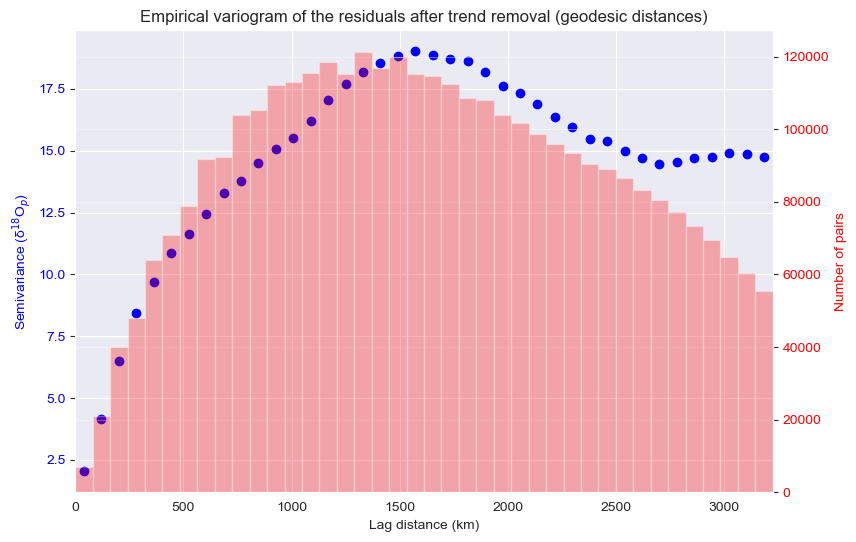

In [ ]:
from pyproj import Geod

da_slice = d18Op.transpose('time','lat','lon').sel(time=time) 

# Get lon, lat, and values (1D)
lon2d, lat2d = np.meshgrid(da_slice['lon'].values, da_slice['lat'].values)
values = da_slice.values

mask = ~np.isnan(values)
lons = lon2d[mask]
lats = lat2d[mask]
vals = values[mask]

print(f"Using {len(vals)} valid grid points")

lonlat = np.column_stack((lons, lats))

# remove linear trend 
X = np.column_stack((lons, lats))
y = vals

linreg = LinearRegression()
linreg.fit(X, y)
trend_pred = linreg.predict(X)

# Compute residuals
residuals = y - trend_pred

print(f"Linear trend coefficients:")
print(f"Intercept = {linreg.intercept_:.3f}")
print(f"b_lon = {linreg.coef_[0]:.3f}, b_lat = {linreg.coef_[1]:.3f}")


# Compute geodesic (great-circle) pairwise distances
geod = Geod(ellps="WGS84")

def geodesic_condensed_distances(lonlat):
    """
    Compute condensed vector of all pairwise geodesic distances (in meters)
    between lon/lat points.
    """
    n = len(lonlat)
    # Upper-triangle indices for unique pairs
    i, j = np.triu_indices(n, k=1)
    lon1, lat1 = lonlat[i, 0], lonlat[i, 1]
    lon2, lat2 = lonlat[j, 0], lonlat[j, 1]
    # geod.inv returns (fwd_azimuth, back_azimuth, distance)
    _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
    return dist

# Compute distances (meters)
distances = geodesic_condensed_distances(lonlat)
print(f"Max pairwise distance: {distances.max()/1000:.1f} km")

# Compute semivariances
# pdist with a custom lambda for squared difference
semivars = pdist(residuals.reshape(-1, 1), lambda u, v: 0.5 * (u - v) ** 2)

# Bin distances into lag classes
n_bins = 40
maxlag = distances.max() * 0.65 
bins = np.linspace(0, maxlag, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Assign each distance to a bin
bin_idx = np.digitize(distances, bins) - 1

# Compute mean semivariance per bin
gamma = np.full(n_bins, np.nan)
counts = np.zeros(n_bins, dtype=int)

for k in range(n_bins):
    sel = bin_idx == k
    counts[k] = np.sum(sel)
    if counts[k] > 0:
        gamma[k] = np.mean(semivars[sel])

# Mask unreliable bins (few pairs)
min_pairs = 30  # threshold of minimum pairs per bin
reliable = counts >= min_pairs

fig, ax1 = plt.subplots(figsize=(9, 6))

# Plot semivariance
ax1.plot(bin_centers[reliable]/1000, gamma[reliable], 'o', color='blue', label='Empirical γ(h)')
ax1.set_xlabel('Lag distance (km)')
ax1.set_ylabel('Semivariance (δ$^{18}$O$_p$)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Overlay pair counts
ax2 = ax1.twinx()
ax2.bar(bin_centers/1000, counts, width=(bin_centers[1]-bin_centers[0])/1000,
        color='red', alpha=0.3, label='Pair counts')
ax2.set_ylabel('Number of pairs', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.xlim(0, maxlag/1000)
plt.title('Empirical variogram of the residuals after trend removal (geodesic distances)')
plt.grid(True, alpha=0.4)
plt.show()



#### *drafts - variograms computations*

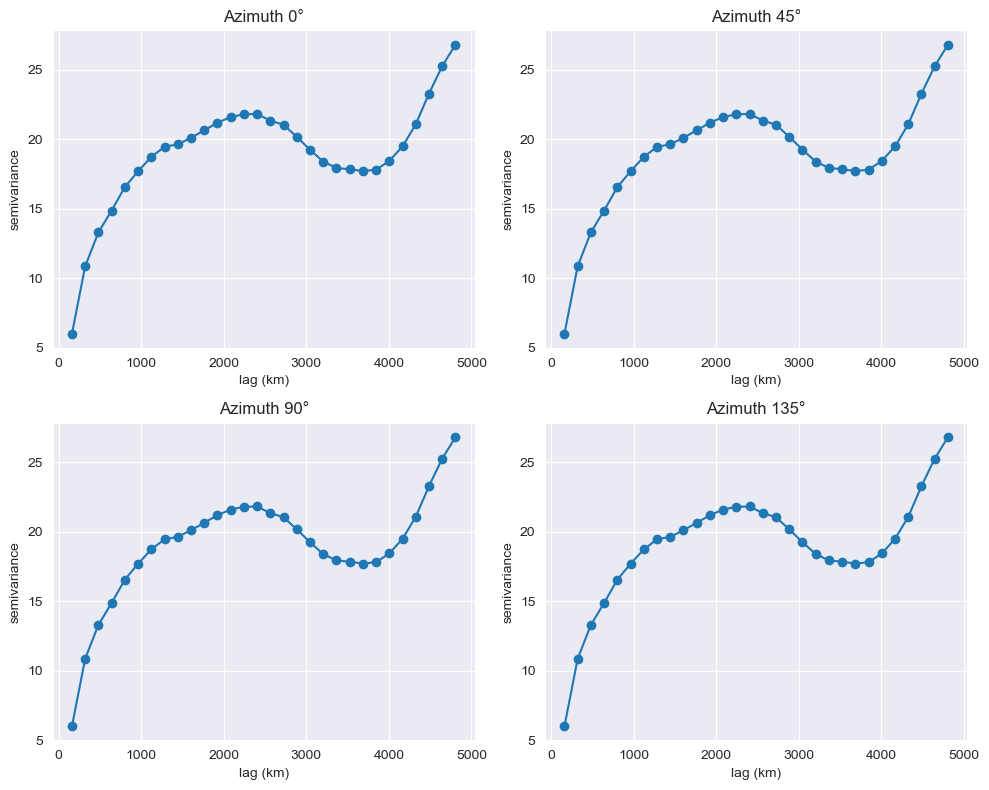

In [142]:
azims = [0, 45, 90, 135]
fig, axs = plt.subplots(2,2, figsize=(10,8))
axs = axs.ravel()
for i, az in enumerate(azims):
    Vi = skg.Variogram(coords, resid, n_lags=30, maxlag=maxlag, normalize=False,
                       azimuth=az, tol=22.5, model='spherical')
    axs[i].plot(Vi.bins/1000, Vi.experimental, 'o-')
    axs[i].set_title(f"Azimuth {az}°")
    axs[i].set_xlabel("lag (km)"); axs[i].set_ylabel("semivariance")
plt.tight_layout()
plt.show()


In [102]:
# coords from meshgrid + ravel
da = d18Op.sel(time='1969-12-31')
lats = da['lat'].values # 64
# print('lats = \n', lats)
lons = da['lon'].values # 87
# print('lons =\n',lons)
lon_grid, lat_grid = np.meshgrid(lons, lats,indexing='ij') # 64*87 = lats*lons
# print('lon_grid = \n',lon_grid)
# print('lat_grid \n',lat_grid)
coords_C = np.column_stack([lon_grid.ravel(order='C'), lat_grid.ravel(order='C')])
# print('longrid ravel order C : \n',lon_grid.ravel(order='C') )
# print('latgrid ravel order C : \n',lat_grid.ravel(order='C') )
# print('coords : ',coords_C)
values_C = da.values.ravel(order='C')
mask_C = ~np.isnan(values_C)
coords_C_valid = coords_C[mask_C]
values_C_valid = values_C[mask_C]

# Project lon/lat in mercator coordinates
gdf = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_C_valid],
    crs="EPSG:4326" # lon,lat system
)
gdf_proj = gdf.to_crs(epsg=3857)
coords_C_proj = np.array([(p.x, p.y) for p in gdf_proj.geometry])


# coords from DataFrame + transformer
df = d18Op.to_dataframe(name='d18Op').reset_index()
# print('df.lon = ',df.lon)
df = df[(df['time'].dt.year==1969) & (df['time'].dt.month==12) & (df['time'].dt.day==31)].dropna(subset='d18Op')

transformer = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True)
df['x'], df['y'] = transformer.transform(df['lon'].values, df['lat'].values)
# print('df lons values \n',df['lon'].values)
# print('df[x]=\n',df['x'])
coords_df = df[['x','y']].values
values_df = df['d18Op'].values

print("C : \n", coords_C_proj)
print("DF : \n", coords_df)

C : 
 [[ 8209054.02082327  4775488.59258073]
 [ 8209054.02082327  4702732.76722572]
 [ 8282302.77572864  4848773.10047032]
 ...
 [14767287.35016782  5694555.88925839]
 [14927609.77049441  6109954.9262203 ]
 [14927609.77049441  6024674.93108585]]
DF : 
 [[ 8209054.02082327  4775488.59258073]
 [ 8209054.02082327  4702732.76722572]
 [ 8282302.77572864  4848773.10047032]
 ...
 [14767287.35016782  5694555.88925839]
 [14927609.77049441  6109954.9262203 ]
 [14927609.77049441  6024674.93108585]]


In [ ]:
# create properly (lon, lat)
df = d18Op.to_dataframe(name='d18Op').reset_index()
df = df[(df['time'].dt.year==1969) & (df['time'].dt.month==12) & (df['time'].dt.day==31)].dropna(subset='d18Op').copy()

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

# transform to Web Mercator (meters)
gdf_proj = gdf.to_crs(epsg=3857)

# extract x,y arrays
xs = gdf_proj.geometry.x.values
ys = gdf_proj.geometry.y.values



[ 8209054.02082327  8209054.02082327  8282302.77572864 ...
 14767287.35016782 14927609.77049441 14927609.77049441]


In [ ]:
# prepare A (meshgrid) and B (to_dataframe) again
da_slice = d18Op.sel(time='1969-12-31')
lons = da_slice['lon'].values
lats = da_slice['lat'].values
lon_grid, lat_grid = np.meshgrid(lons, lats,indexing='ij')   # <- indexing='ij' to preserve order
coords = np.column_stack([lon_grid.ravel(order='C'), lat_grid.ravel(order='C')])
values = da_slice.values.ravel(order='C')
mask = ~np.isnan(values)
coords_A = coords[mask]
vals_A = values[mask]

df = d18Op.to_dataframe(name='d18Op').reset_index()
df = df[(df['time'].dt.year==1969) & (df['time'].dt.month==12) & (df['time'].dt.day==31)].dropna(subset=['d18Op']).copy()
coords_B = df[['lon','lat']].values
vals_B = df['d18Op'].values

print('counts A,B:', coords_A.shape[0], coords_B.shape[0])
print('da_slice.shape, coords grid shape:', da_slice.shape, lon_grid.shape)

# compare lon/lat pairs before projection
setA = set(map(tuple, np.round(coords_A, 6)))
setB = set(map(tuple, np.round(coords_B, 6)))
print('n only in A:', len(setA - setB))
print('n only in B:', len(setB - setA))
# show some examples
print('examples only in A (first 5):', list(setA - setB)[:5])
print('examples only in B (first 5):', list(setB - setA)[:5])

# check lon ranges / ordering
print('lons range (grid):', lons.min(), lons.max())
print('lons range (df):', df['lon'].min(), df['lon'].max())
print('first/last lats:', lats[:3], lats[-3:])
print('unique lat ordering in df head/tail:', df['lat'].unique()[:3], df['lat'].unique()[-3:])

counts A,B: 2779 2779
da_slice.shape, coords grid shape: (87, 64) (87, 64)
n only in A: 0
n only in B: 0
examples only in A (first 5): []
examples only in B (first 5): []
lons range (grid): 73.7431869506836 134.0970001220703
lons range (df): 73.7431869506836 134.0970001220703
first/last lats: [53.10110092 52.44433975 51.82836914] [21.62822914 21.12118912 20.61413956]
unique lat ordering in df head/tail: [39.37471008 38.86766052 39.8817482 ] [51.82836914 53.10110092 52.44433975]


[[13498167.69893585  7001720.79383137]
 [13576224.34292035  7001720.79383137]
 [13655517.56816245  7001720.79383137]
 ...
 [12530199.74754369  2466947.79836194]
 [12237107.05838606  2406334.97568083]
 [12237107.05838606  2345927.87489557]]


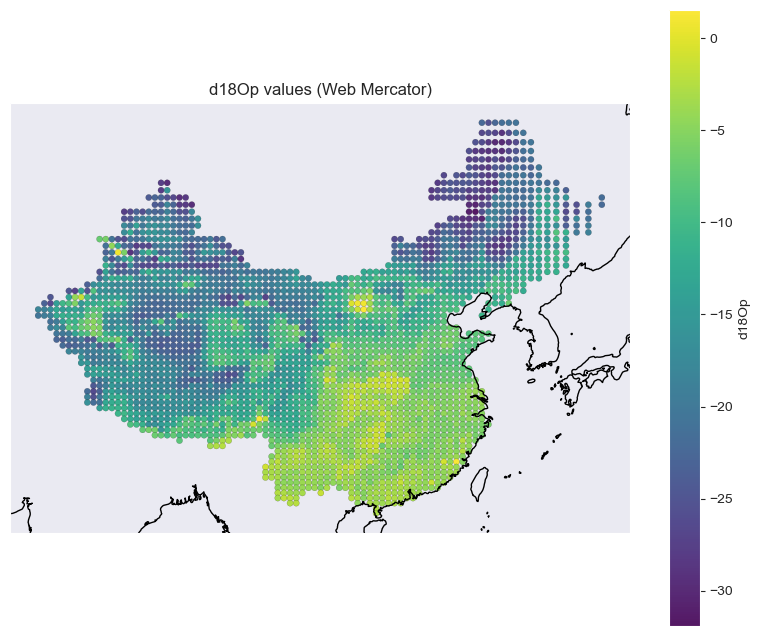

In [130]:
import cartopy.crs as ccrs

# flatten with xarray (no meshgrid/ravel headaches)
stacked = da_slice.stack(point=('lat','lon')).dropna('point')   # or ('lon','lat') to match your desired order
lons_s = stacked['lon'].values
lats_s = stacked['lat'].values
vals_s = stacked.values

# project vectorized
transformer = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True)
xs, ys = transformer.transform(lons_s, lats_s)
coords_proj = np.column_stack([xs, ys])
print(coords_proj)

# fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
# sc = ax.scatter(lons_s, lats_s, c=vals_s, s=20, cmap="viridis", transform=ccrs.PlateCarree(), alpha=0.9, edgecolor="k", linewidth=0.1)
# ax.coastlines(resolution="50m")
# ax.set_title("d18Op values (lon/lat)")
# plt.colorbar(sc, ax=ax, label="d18Op")
# plt.show()

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.Mercator()})
sc = ax.scatter(xs, ys, c=vals_s, s=20, cmap="viridis", transform=ccrs.Mercator(), alpha=0.9, edgecolor="k", linewidth=0.1)
ax.coastlines(resolution="50m")
ax.set_title("d18Op values (Web Mercator)")
plt.colorbar(sc, ax=ax, label="d18Op")
plt.show()


#### Directional variograms (gstat)

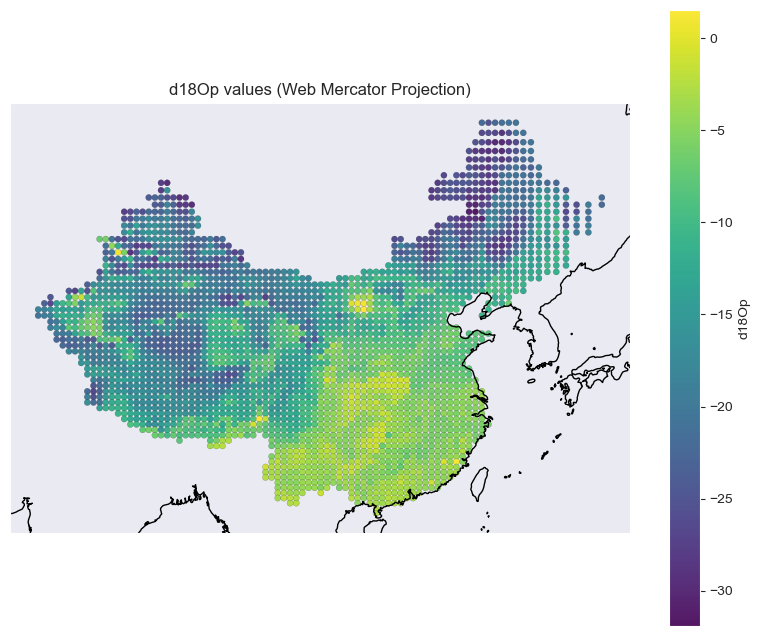

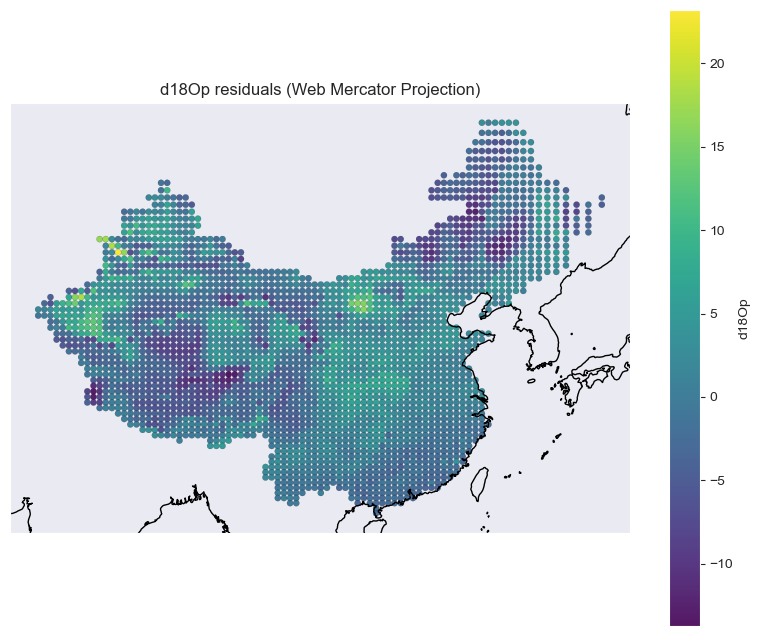

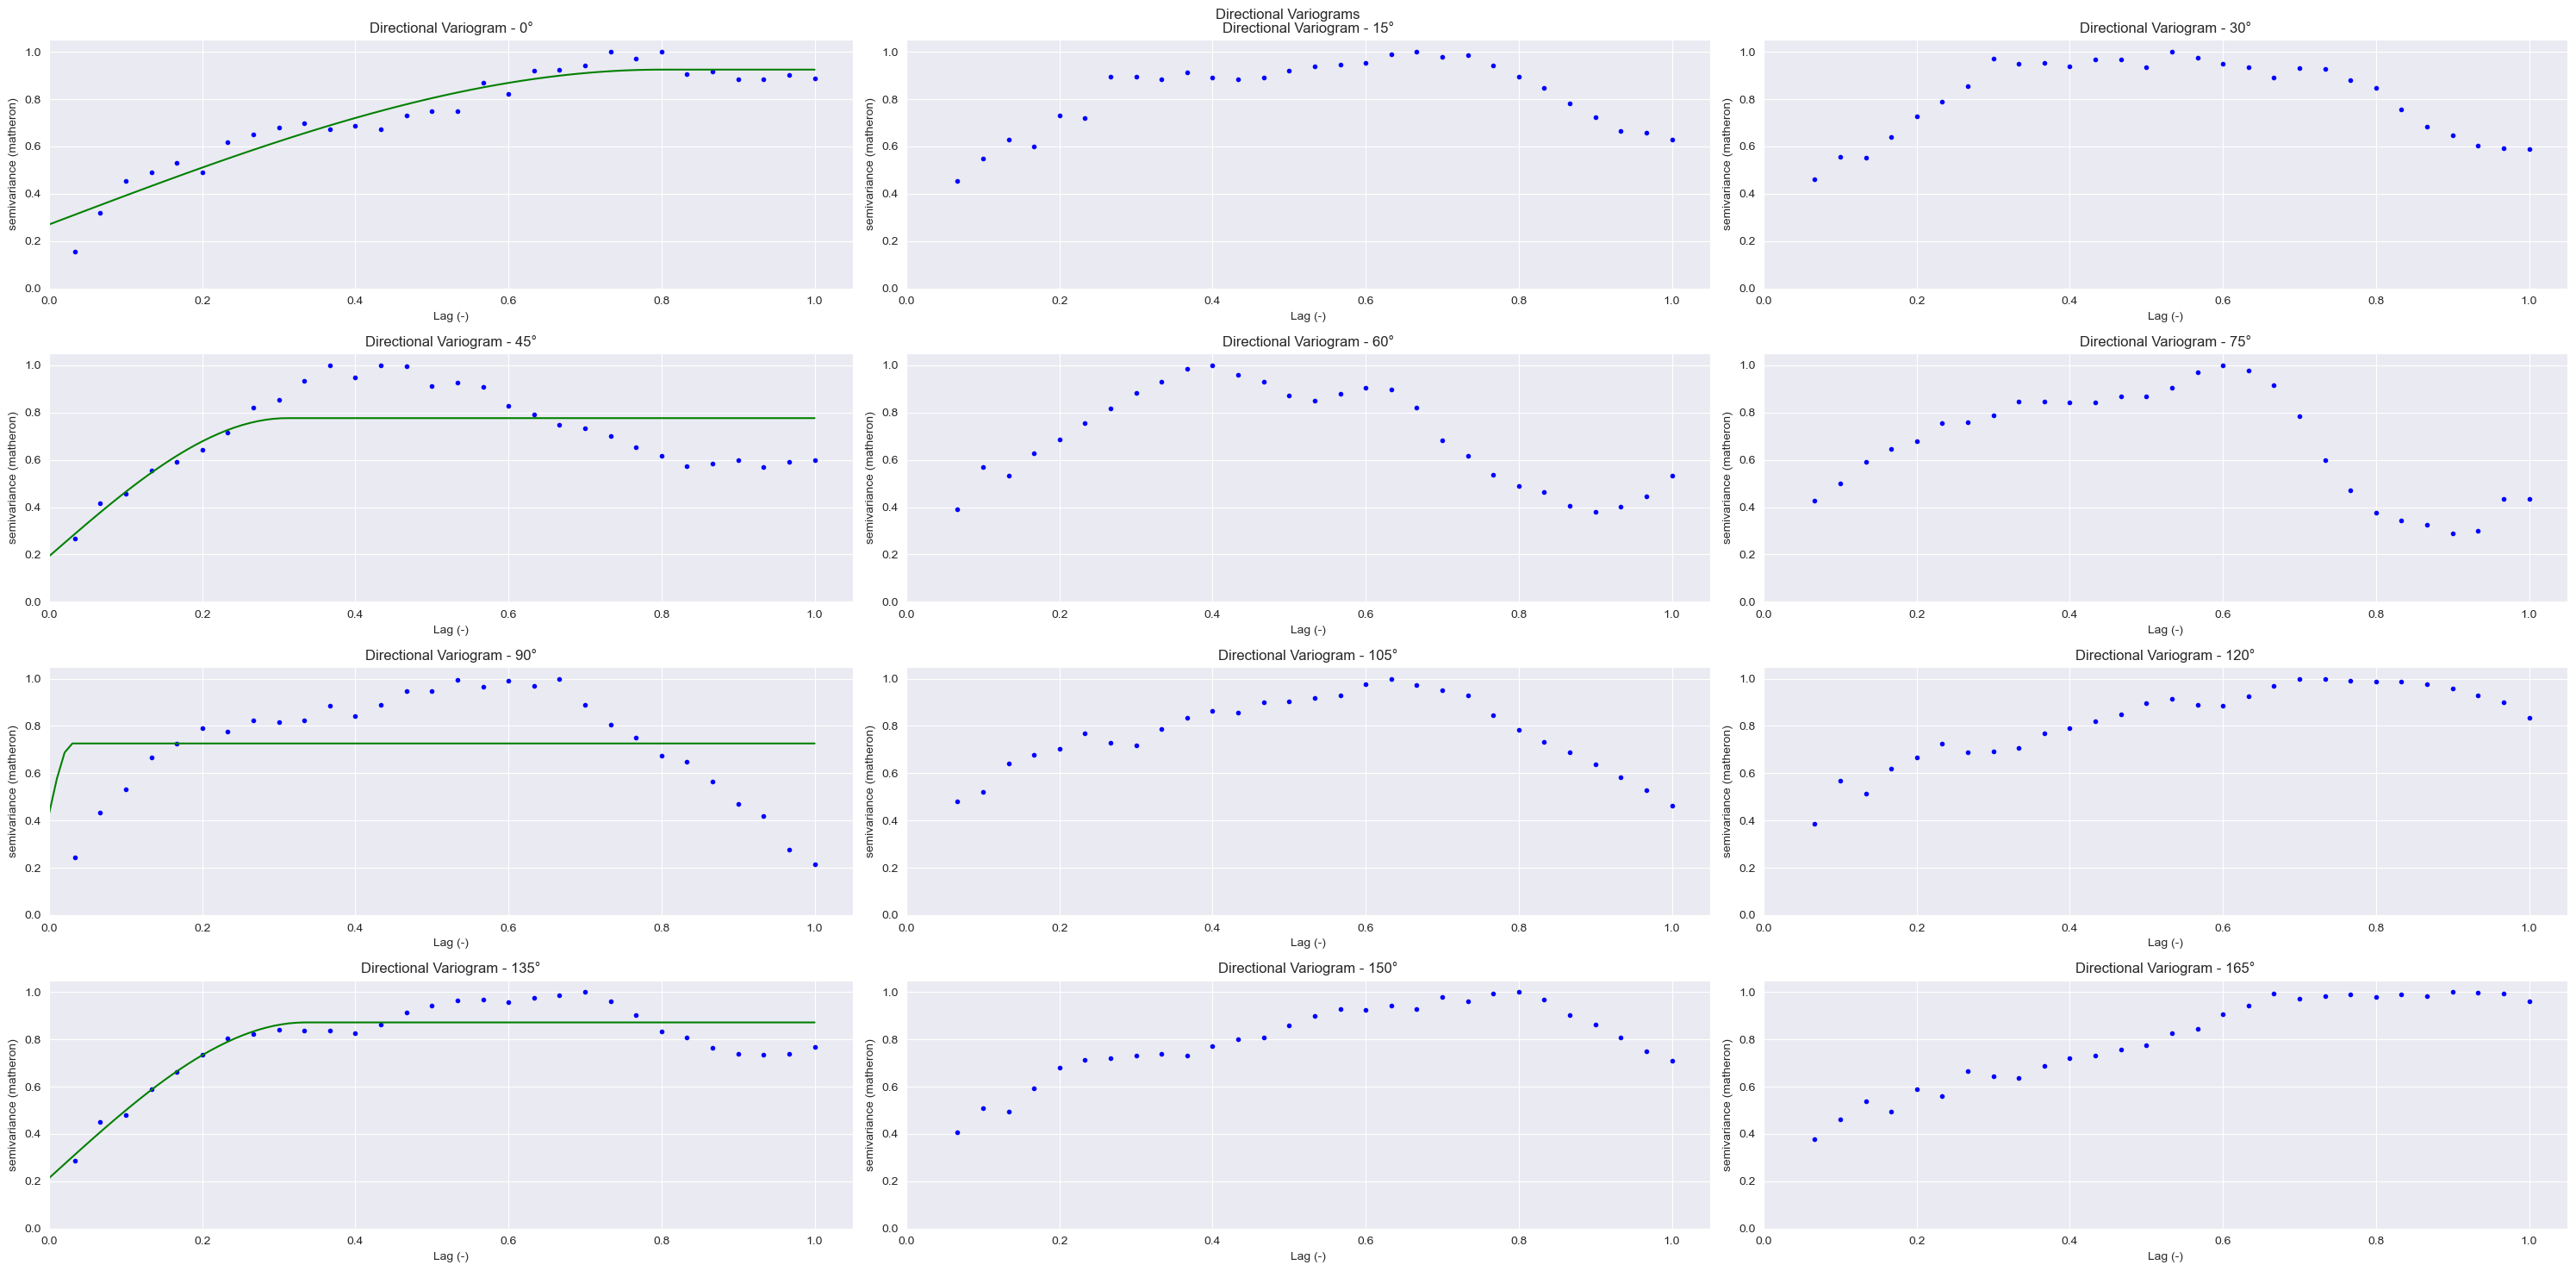

Range in direction 0°: 17.492684271784128
Range in direction 15°: 12.86791151294003
Range in direction 30°: 7.295793787042099
Range in direction 45°: 13.584480936611275
Range in direction 60°: 11.496192222257998
Range in direction 75°: 10.96219755975843
Range in direction 90°: 6.2298512835356785
Range in direction 105°: 8.977267580820966
Range in direction 120°: 12.943225505399013
Range in direction 135°: 14.712710242395863
Range in direction 150°: 13.054136046353662
Range in direction 165°: 17.632737933502888
Anisotropy Ratio: 2.8303625770494536
Anisotropy Direction: 165°


In [33]:
da_slice = d18Op.sel(time=time)

# flatten with xarray (no meshgrid/ravel headaches)
stacked = da_slice.stack(point=('lat','lon')).dropna('point') 
lons_s = stacked['lon'].values
lats_s = stacked['lat'].values
vals_s = stacked.values

# project vectorized
transformer = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True)
xs, ys = transformer.transform(lons_s, lats_s)
coords_proj = np.column_stack([xs, ys])

# detrend: fit plane z ~ x + y and subtract it ###### to comment if needed (and change resid to vals_s below)
XY = np.column_stack((xs, ys))
lr = LinearRegression().fit(XY, vals_s)
trend = lr.predict(XY)
resid = vals_s - trend

# show the map again 
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.Mercator()})
sc = ax.scatter(coords_proj[:,0],coords_proj[:,1], c=vals_s, s=20, cmap="viridis", transform=ccrs.Mercator(), alpha=0.9, edgecolor="k", linewidth=0.1)
ax.coastlines(resolution="50m")
ax.set_title("d18Op values (Web Mercator Projection)")
plt.colorbar(sc, ax=ax, label="d18Op")
plt.show()

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.Mercator()})
sc = ax.scatter(coords_proj[:,0],coords_proj[:,1], c=resid, s=20, cmap="viridis", transform=ccrs.Mercator(), alpha=0.9, edgecolor="k", linewidth=0.1)
ax.coastlines(resolution="50m")
ax.set_title("d18Op residuals (Web Mercator Projection)")
plt.colorbar(sc, ax=ax, label="d18Op")
plt.show()

# Compute directional variogram
directions = [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165]
ranges = []
fig, axes = plt.subplots(4, 3, figsize=(30, 15))
axes = axes.flatten()
for i, direction in enumerate(directions):
    V_dir = skg.DirectionalVariogram(
        coords_proj,
        resid,
        n_lags=30,
        maxlag=3500000,
        model='spherical',
        use_nugget=True,
        normalize=True,
        azimuth=direction,
        tolerance = 12.5 
    )
    ranges.append(V_dir.parameters[1])
    V_dir.plot(axes=axes[i], show=False, grid=False)
    axes[i].set_title(f'Directional Variogram - {direction}°')
plt.suptitle('Directional Variograms')
plt.tight_layout()
plt.show()

for dir, r in zip(directions, ranges):
    print(f'Range in direction {dir}°: {r}')

anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')

# print anisotropy direction
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {directions[max_range_index]}°')


### Global variogram

100%|██████████| 148/148 [02:10<00:00,  1.13it/s]


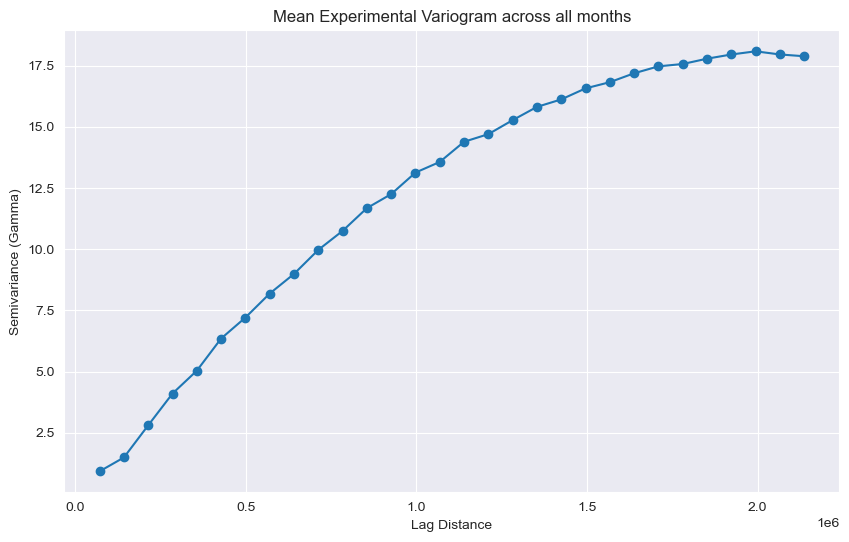

In [35]:
from skgstat import Variogram
import numpy as np
import pandas as pd
from tqdm import tqdm

def compute_variogram_for_month(df_month, sample_size=3000, trend_removal=False):
    """Compute experimental variogram for one month with sampling.
    """
    # check if the month contains too much samples. If so, sample it down to the sample_size.
    if len(df_month) > sample_size:
        print('downsampling')
        df_month = df_month.sample(sample_size, random_state=42)
    vals = df_month['d18Op'].values
    if trend_removal :
        # Remove trend by fitting a plane 
        XY = np.column_stack((df_month['x'], df_month['y']))
        lr = LinearRegression().fit(XY, df_month['d18Op'])
        trend = lr.predict(XY)
        vals = df_month['d18Op'] - trend
    
    # Compute the variogram 
    V = Variogram(
        df_month[['x','y']].values,
        vals,
        n_lags=30,
        normalize=True,
        maxlag='median',
        use_nugget=True,
        model='spherical'
    )
    # return only bins and exp values to avoid heavy memory usage (V contains the full matrices of pairs etc)
    # plot the variogram 
    # plt.figure(figsize=(8,5))
    # V.plot(show=False, grid=False)
    # plt.title(f'Experimental Variogram for month {df_month["time"].iloc[0]}')
    # plt.show()
    return V.bins, V.experimental

# convert the xarray into dataframe
df = d18Op.to_dataframe(name='d18Op').reset_index().dropna()
df = df[ (df['time'].dt.month == 3)] # winter #(df['time'].dt.year==1969) &

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
df['x'], df['y'] = transformer.transform(df['lon'].values, df['lat'].values)
bins, gammas = None, []
for t, g in tqdm(df.groupby('time')):
    if g['d18Op'].notna().sum() < 30:
        continue
    try:
        b, g_exp = compute_variogram_for_month(g,trend_removal=True)
        if bins is None:
            bins = b
        gammas.append(g_exp)
    except Exception as e:
        print(f"Skipped {t}: {e}")

# Compute mean variogram
mean_gamma = np.nanmean(np.vstack(gammas), axis=0)
mean_df = pd.DataFrame({'lag': bins, 'gamma': mean_gamma})

# plot mean variogram
plt.figure(figsize=(10,6))
plt.plot(mean_df['lag'], mean_df['gamma'], marker='o')
plt.title('Mean Experimental Variogram across all months')
plt.xlabel('Lag Distance')
plt.ylabel('Semivariance (Gamma)')
plt.grid('minor')
plt.show()